# Phase 5 – Demand Forecasting

## Objective

This notebook develops a demand forecasting model for Project FORESIGHT using historical sales data. The goal is to predict future weekly product demand at the SKU level to support inventory planning, reduce stockouts, and minimize excess inventory.

The forecasting workflow includes:

- Preparing weekly SKU-level demand data
- Building a seasonal naive baseline model
- Training and evaluating a forecasting model
- Comparing model performance using WAPE
- Performing rolling-origin cross-validation
- Generating business-ready demand forecasts

The final forecasting model will be used in the next phase for inventory risk scoring and decision support.

## Import Libraries

The following libraries are imported to support data manipulation, visualization, forecasting, and model evaluation throughout this notebook.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Utilities
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


### Import Summary

The required Python libraries for data manipulation, visualization, time-series validation, and model evaluation have been imported successfully. These libraries will be used throughout the demand forecasting workflow.

## Load Cleaned Datasets

The cleaned datasets generated during the data cleaning phase are loaded for demand forecasting. The sales transaction dataset is the primary source used to prepare weekly SKU-level demand, while the SKU master dataset provides product-level information.

In [3]:
sales_df = pd.read_csv(
    "../data/processed/sales_transactions_clean.csv",
    parse_dates=["date"]
)

sku_df = pd.read_csv(
    "../data/processed/sku_master_clean.csv"
)

In [4]:
print("Sales Dataset Shape :", sales_df.shape)
print("SKU Dataset Shape   :", sku_df.shape)

Sales Dataset Shape : (9945511, 11)
SKU Dataset Shape   : (5000, 7)


In [5]:
sales_df.head()

,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id
0,2025-04-02,RCPT00000001,ST16,SKU02498,CUST01410,1,2379.11,2379.11,In-Store,0.0,NaN
1,2025-04-02,RCPT00000001,ST16,SKU04596,CUST01410,3,335.55,1006.65,In-Store,0.0,NaN
2,2022-04-24,RCPT00000002,ST15,SKU00078,CUST00134,1,820.53,820.53,Online,0.0,NaN
3,2022-04-24,RCPT00000002,ST15,SKU00554,CUST00134,2,88.32,176.64,Online,0.0,NaN
4,2024-09-22,RCPT00000003,ST20,SKU03727,CUST08826,1,1660.93,1660.93,Online,0.0,NaN


In [6]:
sku_df.head()

,sku_id,sku_name,category,subcategory,unit_price,cost_price,brand
0,SKU00001,NutriPlus Cookware Large,Home & Kitchen,Cookware,813.41,619.77,NutriPlus
1,SKU00002,CrispKing Bread Family Pack,Dairy & Bakery,Bread,70.38,49.57,CrispKing
2,SKU00003,SoftTouch Notebooks 2L,Stationery & Office,Notebooks,151.28,83.67,SoftTouch
3,SKU00004,SunriseFoods Eggs Large,Dairy & Bakery,Eggs,233.64,156.32,SunriseFoods
4,SKU00005,SunriseFoods Pest Control Pack of 6,Home Care,Pest Control,138.50,83.46,SunriseFoods


In [7]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9945511 entries, 0 to 9945510
Data columns (total 11 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[us]
 1   receipt_id    str           
 2   store_id      str           
 3   sku_id        str           
 4   customer_id   str           
 5   quantity      int64         
 6   unit_price    float64       
 7   total_value   float64       
 8   channel       str           
 9   discount_pct  float64       
 10  promo_id      str           
dtypes: datetime64[us](1), float64(3), int64(1), str(6)
memory usage: 834.7 MB


In [8]:
sku_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku_id       5000 non-null   str    
 1   sku_name     5000 non-null   str    
 2   category     5000 non-null   str    
 3   subcategory  5000 non-null   str    
 4   unit_price   5000 non-null   float64
 5   cost_price   5000 non-null   float64
 6   brand        5000 non-null   str    
dtypes: float64(2), str(5)
memory usage: 273.6 KB


In [9]:
print("Missing Values in Sales Dataset")
print(sales_df.isnull().sum())

Missing Values in Sales Dataset
date                  0
receipt_id            0
store_id              0
sku_id                0
customer_id           0
quantity              0
unit_price            0
total_value           0
channel               0
discount_pct          0
promo_id        7855345
dtype: int64


In [10]:
print("Missing Values in SKU Dataset")
print(sku_df.isnull().sum())

Missing Values in SKU Dataset
sku_id         0
sku_name       0
category       0
subcategory    0
unit_price     0
cost_price     0
brand          0
dtype: int64


In [11]:
print("Start Date :", sales_df["date"].min())
print("End Date   :", sales_df["date"].max())

Start Date : 2022-01-01 00:00:00
End Date   : 2025-12-31 00:00:00


### Dataset Summary

The cleaned sales and SKU datasets were loaded successfully. The sales dataset contains historical transaction records with correctly formatted dates and numerical fields. The data spans multiple years, making it suitable for preparing weekly demand data and developing forecasting models.

## Prepare Weekly SKU-Level Demand

Demand forecasting is performed at the weekly SKU level. Daily sales transactions are aggregated into weekly demand by summing the quantity sold for each product. This creates the forecasting dataset used throughout the remaining sections.

In [12]:
sales_df["week_start"] = sales_df["date"].dt.to_period("W").apply(lambda x: x.start_time)

In [13]:
sales_df[["date", "week_start"]].head()

,date,week_start
0,2025-04-02,2025-03-31
1,2025-04-02,2025-03-31
2,2022-04-24,2022-04-18
3,2022-04-24,2022-04-18
4,2024-09-22,2024-09-16


In [14]:
weekly_sales = (
    sales_df
    .groupby(["sku_id", "week_start"], as_index=False)
    .agg(
        weekly_quantity=("quantity", "sum"),
        weekly_sales=("total_value", "sum")
    )
)

In [15]:
print("Weekly Dataset Shape:", weekly_sales.shape)

Weekly Dataset Shape: (1033143, 4)


In [16]:
weekly_sales.head()

,sku_id,week_start,weekly_quantity,weekly_sales
0,SKU00001,2021-12-27,3,2440.23
1,SKU00001,2022-01-03,14,11387.74
2,SKU00001,2022-01-10,29,23588.89
3,SKU00001,2022-01-17,12,9760.92
4,SKU00001,2022-01-24,15,12201.15


In [17]:
weekly_sales.isnull().sum()

sku_id             0
week_start         0
weekly_quantity    0
weekly_sales       0
dtype: int64

In [18]:
weekly_sales.duplicated(
    subset=["sku_id", "week_start"]
).sum()

np.int64(0)

In [19]:
print("Total Weeks:", weekly_sales["week_start"].nunique())

Total Weeks: 210


In [20]:
print("Total SKUs:", weekly_sales["sku_id"].nunique())

Total SKUs: 5000


In [21]:
overall_weekly = (
    weekly_sales
    .groupby("week_start")["weekly_quantity"]
    .sum()
    .reset_index()
)

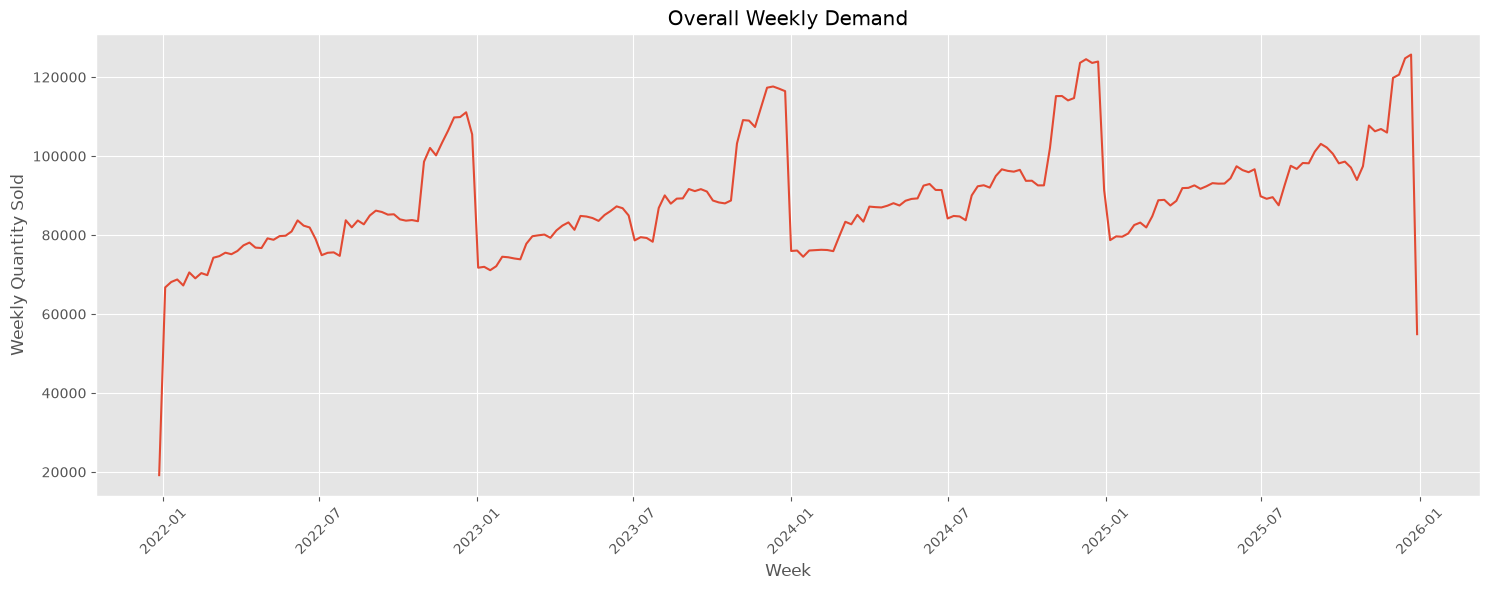

In [22]:
plt.figure(figsize=(15,6))

plt.plot(
    overall_weekly["week_start"],
    overall_weekly["weekly_quantity"]
)

plt.title("Overall Weekly Demand")

plt.xlabel("Week")

plt.ylabel("Weekly Quantity Sold")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Weekly Demand Summary

Historical daily sales transactions were successfully aggregated into weekly SKU-level demand. The resulting dataset contains one record for each SKU and week, providing the required structure for time-series forecasting. The weekly aggregation reduces day-to-day noise while preserving overall demand trends, making it suitable for baseline forecasting, model training, and evaluation.

## Train-Test Split

For time-series forecasting, the data is split chronologically rather than randomly. Historical weeks are used for training, while the most recent weeks are reserved for testing. This prevents data leakage and ensures that future information is never used during model training.

In [23]:
weekly_sales = weekly_sales.sort_values(
    ["sku_id", "week_start"]
).reset_index(drop=True)

In [24]:
weekly_sales.head()

,sku_id,week_start,weekly_quantity,weekly_sales
0,SKU00001,2021-12-27,3,2440.23
1,SKU00001,2022-01-03,14,11387.74
2,SKU00001,2022-01-10,29,23588.89
3,SKU00001,2022-01-17,12,9760.92
4,SKU00001,2022-01-24,15,12201.15


In [25]:
all_weeks = sorted(weekly_sales["week_start"].unique())

print("Total Weeks:", len(all_weeks))
print("First Week:", all_weeks[0])
print("Last Week :", all_weeks[-1])

Total Weeks: 210
First Week: 2021-12-27 00:00:00
Last Week : 2025-12-29 00:00:00


In [26]:
test_weeks = all_weeks[-12:]

test_weeks

[Timestamp('2025-10-13 00:00:00'),
 Timestamp('2025-10-20 00:00:00'),
 Timestamp('2025-10-27 00:00:00'),
 Timestamp('2025-11-03 00:00:00'),
 Timestamp('2025-11-10 00:00:00'),
 Timestamp('2025-11-17 00:00:00'),
 Timestamp('2025-11-24 00:00:00'),
 Timestamp('2025-12-01 00:00:00'),
 Timestamp('2025-12-08 00:00:00'),
 Timestamp('2025-12-15 00:00:00'),
 Timestamp('2025-12-22 00:00:00'),
 Timestamp('2025-12-29 00:00:00')]

In [27]:
train_df = weekly_sales[
    ~weekly_sales["week_start"].isin(test_weeks)
].copy()

test_df = weekly_sales[
    weekly_sales["week_start"].isin(test_weeks)
].copy()

In [28]:
print("Training Dataset :", train_df.shape)
print("Testing Dataset  :", test_df.shape)

Training Dataset : (973719, 4)
Testing Dataset  : (59424, 4)


In [29]:
print("Training Period")
print(train_df["week_start"].min())
print(train_df["week_start"].max())

print()

print("Testing Period")
print(test_df["week_start"].min())
print(test_df["week_start"].max())

Training Period
2021-12-27 00:00:00
2025-10-06 00:00:00

Testing Period
2025-10-13 00:00:00
2025-12-29 00:00:00


In [30]:
overlap = set(train_df["week_start"]).intersection(
    set(test_df["week_start"])
)

print("Overlapping Weeks:", len(overlap))

Overlapping Weeks: 0


### Train-Test Split Summary

The weekly demand dataset was split chronologically into training and testing sets. The final 12 weeks were reserved for testing, while all earlier weeks were used for model development. This approach prevents data leakage and accurately simulates real-world forecasting, where future demand is predicted using only historical information.

## Seasonal Naive Baseline

A seasonal naive baseline model is created to establish a benchmark for evaluating forecasting performance. For each SKU, the forecast for the current week is taken as the demand observed in the previous week. This simple approach provides a reference point against which more advanced forecasting models can be compared.

In [31]:
train_df = train_df.sort_values(
    ["sku_id", "week_start"]
).reset_index(drop=True)

In [32]:
train_df["baseline_forecast"] = (
    train_df
    .groupby("sku_id")["weekly_quantity"]
    .shift(1)
)

In [33]:
train_df[
    [
        "sku_id",
        "week_start",
        "weekly_quantity",
        "baseline_forecast"
    ]
].head(15)

,sku_id,week_start,weekly_quantity,baseline_forecast
0,SKU00001,2021-12-27,3,NaN
1,SKU00001,2022-01-03,14,3.0
2,SKU00001,2022-01-10,29,14.0
3,SKU00001,2022-01-17,12,29.0
4,SKU00001,2022-01-24,15,12.0
5,SKU00001,2022-01-31,13,15.0
6,SKU00001,2022-02-07,28,13.0
7,SKU00001,2022-02-14,29,28.0
8,SKU00001,2022-02-21,5,29.0
9,SKU00001,2022-02-28,32,5.0


In [34]:
baseline_df = train_df.dropna(
    subset=["baseline_forecast"]
).copy()

In [35]:
print("Baseline Dataset Shape:", baseline_df.shape)

Baseline Dataset Shape: (968719, 5)


In [36]:
baseline_df[
    [
        "weekly_quantity",
        "baseline_forecast"
    ]
].isnull().sum()

weekly_quantity      0
baseline_forecast    0
dtype: int64

In [37]:
baseline_df[
    [
        "week_start",
        "weekly_quantity",
        "baseline_forecast"
    ]
].head(10)

,week_start,weekly_quantity,baseline_forecast
1,2022-01-03,14,3.0
2,2022-01-10,29,14.0
3,2022-01-17,12,29.0
4,2022-01-24,15,12.0
5,2022-01-31,13,15.0
6,2022-02-07,28,13.0
7,2022-02-14,29,28.0
8,2022-02-21,5,29.0
9,2022-02-28,32,5.0
10,2022-03-07,12,32.0


In [38]:
sample_sku = baseline_df["sku_id"].iloc[0]

sample_data = baseline_df[
    baseline_df["sku_id"] == sample_sku
]

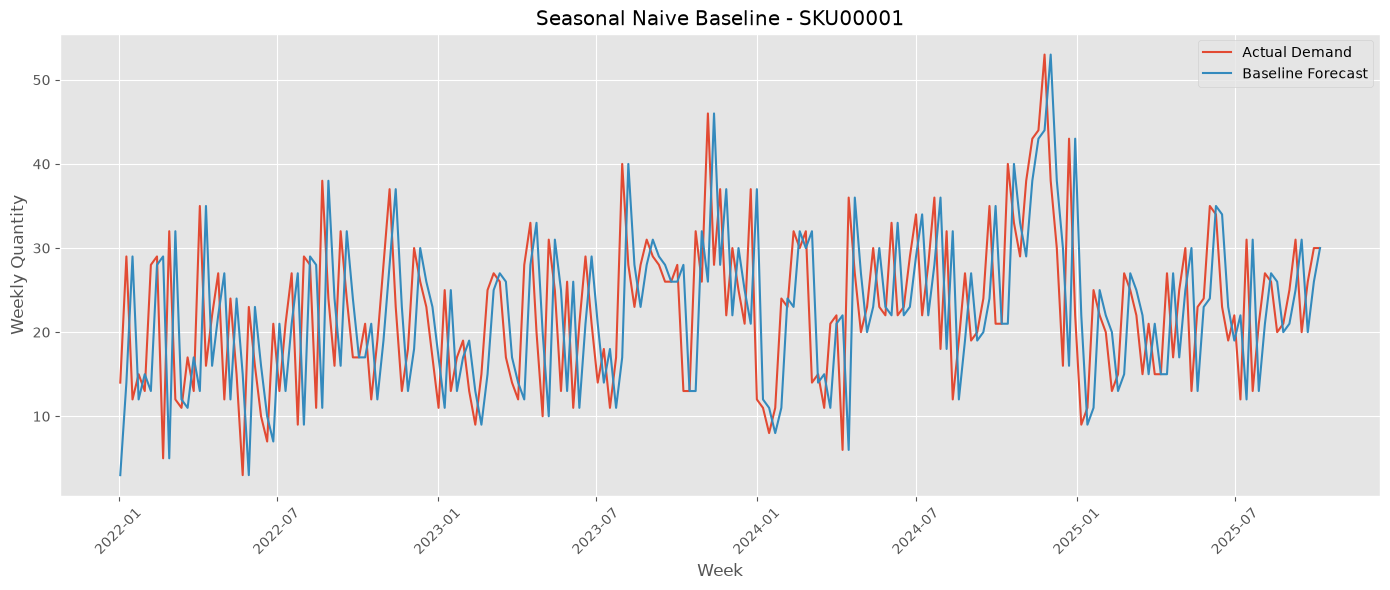

In [39]:
plt.figure(figsize=(14,6))

plt.plot(
    sample_data["week_start"],
    sample_data["weekly_quantity"],
    label="Actual Demand"
)

plt.plot(
    sample_data["week_start"],
    sample_data["baseline_forecast"],
    label="Baseline Forecast"
)

plt.title(f"Seasonal Naive Baseline - {sample_sku}")

plt.xlabel("Week")

plt.ylabel("Weekly Quantity")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Seasonal Naive Baseline Summary

A seasonal naive baseline model was created by using the previous week's demand as the forecast for the current week. This baseline provides a simple benchmark for evaluating the performance of advanced forecasting models. The baseline forecast will be assessed using WAPE in the next section.

## Baseline Model Evaluation

The seasonal naive baseline is evaluated using Weighted Absolute Percentage Error (WAPE). WAPE measures the forecasting error relative to the total observed demand, making it a suitable metric for inventory planning and demand forecasting. The baseline WAPE will serve as the benchmark for evaluating the forecasting model.

In [40]:
baseline_df["absolute_error"] = (
    baseline_df["weekly_quantity"] -
    baseline_df["baseline_forecast"]
).abs()

In [41]:
baseline_df[
    [
        "weekly_quantity",
        "baseline_forecast",
        "absolute_error"
    ]
].head()

,weekly_quantity,baseline_forecast,absolute_error
1,14,3.0,11.0
2,29,14.0,15.0
3,12,29.0,17.0
4,15,12.0,3.0
5,13,15.0,2.0


In [42]:
wape = (
    baseline_df["absolute_error"].sum()
    /
    baseline_df["weekly_quantity"].sum()
) * 100

print(f"Baseline WAPE: {wape:.2f}%")

Baseline WAPE: 36.09%


In [43]:
mae = mean_absolute_error(
    baseline_df["weekly_quantity"],
    baseline_df["baseline_forecast"]
)

print(f"Baseline MAE: {mae:.2f}")

Baseline MAE: 6.49


In [44]:
rmse = np.sqrt(
    mean_squared_error(
        baseline_df["weekly_quantity"],
        baseline_df["baseline_forecast"]
    )
)

print(f"Baseline RMSE: {rmse:.2f}")

Baseline RMSE: 11.49


In [45]:
baseline_metrics = pd.DataFrame({
    "Metric": ["WAPE", "MAE", "RMSE"],
    "Value": [
        round(wape, 2),
        round(mae, 2),
        round(rmse, 2)
    ]
})

baseline_metrics

,Metric,Value
0,WAPE,36.09
1,MAE,6.49
2,RMSE,11.49


### Baseline Evaluation Summary

The seasonal naive baseline was evaluated using WAPE, MAE, and RMSE. These metrics establish the benchmark that the forecasting model must outperform. A lower WAPE indicates improved forecasting accuracy and better support for inventory planning decisions.

## Forecast Model Preparation

To train a forecasting model, the weekly demand dataset is prepared by creating time-based features and selecting the target variable. These features provide historical context while ensuring that no future information is used during model training.

In [46]:
model_data = weekly_sales.copy()

model_data["year"] = model_data["week_start"].dt.year
model_data["month"] = model_data["week_start"].dt.month
model_data["quarter"] = model_data["week_start"].dt.quarter
model_data["week"] = model_data["week_start"].dt.isocalendar().week.astype(int)

In [47]:
model_data["sku_code"] = (
    model_data["sku_id"]
    .astype("category")
    .cat.codes
)

In [48]:
model_data.head()

,sku_id,week_start,weekly_quantity,weekly_sales,year,month,quarter,week,sku_code
0,SKU00001,2021-12-27,3,2440.23,2021,12,4,52,0
1,SKU00001,2022-01-03,14,11387.74,2022,1,1,1,0
2,SKU00001,2022-01-10,29,23588.89,2022,1,1,2,0
3,SKU00001,2022-01-17,12,9760.92,2022,1,1,3,0
4,SKU00001,2022-01-24,15,12201.15,2022,1,1,4,0


In [49]:
features = [
    "sku_code",
    "year",
    "month",
    "quarter",
    "week"
]

target = "weekly_quantity"

In [50]:
train_model = model_data[
    model_data["week_start"] < test_weeks[0]
].copy()

test_model = model_data[
    model_data["week_start"] >= test_weeks[0]
].copy()

In [51]:
X_train = train_model[features]
y_train = train_model[target]

X_test = test_model[features]
y_test = test_model[target]

In [52]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (973719, 5)
y_train: (973719,)
X_test : (59424, 5)
y_test : (59424,)


### Model Preparation Summary

The weekly demand dataset was prepared for machine learning by creating time-based features and encoding SKU identifiers. The data was split chronologically into training and testing sets, ensuring that future observations were excluded from the training process. These prepared datasets will be used to train and evaluate the forecasting model.

## Forecast Model Training

A Random Forest Regressor is trained using the prepared weekly demand dataset. The model learns historical demand patterns from time-based features and product identifiers. Its performance will be compared against the seasonal naive baseline using WAPE.

In [53]:
from sklearn.ensemble import RandomForestRegressor

In [54]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [55]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [56]:
print(rf_model)

RandomForestRegressor(n_jobs=-1, random_state=42)


### Model Training Summary

A Random Forest Regressor was successfully trained using the historical weekly demand dataset. The model is now ready to generate demand forecasts for the testing period. Its forecasting performance will be evaluated and compared with the seasonal naive baseline in the next section.

## Model Prediction and Evaluation

The trained Random Forest model is used to predict weekly demand for the testing period. The forecasting performance is evaluated using WAPE, MAE, and RMSE. These metrics are compared with the seasonal naive baseline to determine whether the forecasting model provides improved accuracy.

In [57]:
y_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [58]:
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

prediction_df.head()

,Actual,Predicted
198,22,33.09
199,24,32.85
200,32,30.30
201,37,39.37
202,20,41.42


In [59]:
model_wape = (
    np.abs(y_test - y_pred).sum()
    /
    y_test.sum()
) * 100

print(f"Model WAPE: {model_wape:.2f}%")

Model WAPE: 36.30%


In [60]:
model_mae = mean_absolute_error(
    y_test,
    y_pred
)

print(f"Model MAE: {model_mae:.2f}")

Model MAE: 7.70


In [61]:
model_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print(f"Model RMSE: {model_rmse:.2f}")

Model RMSE: 37.82


In [62]:
comparison = pd.DataFrame({
    "Metric": ["WAPE", "MAE", "RMSE"],
    "Baseline": [
        round(wape, 2),
        round(mae, 2),
        round(rmse, 2)
    ],
    "Random Forest": [
        round(model_wape, 2),
        round(model_mae, 2),
        round(model_rmse, 2)
    ]
})

comparison

,Metric,Baseline,Random Forest
0,WAPE,36.09,36.30
1,MAE,6.49,7.70
2,RMSE,11.49,37.82


In [63]:
if model_wape < wape:
    print("✅ Random Forest outperformed the Seasonal Naive Baseline.")
else:
    print("⚠️ Random Forest did not outperform the Seasonal Naive Baseline.")

⚠️ Random Forest did not outperform the Seasonal Naive Baseline.


In [64]:
print("Baseline WAPE :", round(wape, 2))
print("Model WAPE    :", round(model_wape, 2))

print()

print("Baseline MAE  :", round(mae, 2))
print("Model MAE     :", round(model_mae, 2))

print()

print("Baseline RMSE :", round(rmse, 2))
print("Model RMSE    :", round(model_rmse, 2))

Baseline WAPE : 36.09
Model WAPE    : 36.3

Baseline MAE  : 6.49
Model MAE     : 7.7

Baseline RMSE : 11.49
Model RMSE    : 37.82


## Lag Feature Engineering

Historical demand is one of the strongest predictors of future demand. Lag features are created by using demand from previous weeks. These features enable the forecasting model to learn temporal demand patterns while preventing data leakage.

In [65]:
model_data = model_data.sort_values(
    ["sku_id", "week_start"]
)

model_data["lag_1"] = (
    model_data
    .groupby("sku_id")["weekly_quantity"]
    .shift(1)
)

model_data["lag_2"] = (
    model_data
    .groupby("sku_id")["weekly_quantity"]
    .shift(2)
)

model_data["lag_4"] = (
    model_data
    .groupby("sku_id")["weekly_quantity"]
    .shift(4)
)

In [66]:
model_data["rolling_mean_4"] = (
    model_data
    .groupby("sku_id")["weekly_quantity"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

In [67]:
model_data = model_data.dropna().reset_index(drop=True)

In [68]:
model_data.head()

,sku_id,week_start,weekly_quantity,weekly_sales,year,month,quarter,week,sku_code,lag_1,lag_2,lag_4,rolling_mean_4
0,SKU00001,2022-01-24,15,12201.15,2022,1,1,4,0,12.0,29.0,3.0,14.50
1,SKU00001,2022-01-31,13,10574.33,2022,1,1,5,0,15.0,12.0,14.0,17.50
2,SKU00001,2022-02-07,28,22775.48,2022,2,1,6,0,13.0,15.0,29.0,17.25
3,SKU00001,2022-02-14,29,23588.89,2022,2,1,7,0,28.0,13.0,12.0,17.00
4,SKU00001,2022-02-21,5,4067.05,2022,2,1,8,0,29.0,28.0,15.0,21.25


In [69]:
train_model = model_data[
    model_data["week_start"] < test_weeks[0]
].copy()

test_model = model_data[
    model_data["week_start"] >= test_weeks[0]
].copy()

print("Train Shape:", train_model.shape)
print("Test Shape :", test_model.shape)

Train Shape: (953719, 13)
Test Shape : (59424, 13)


In [70]:
features = [
    "sku_code",
    "year",
    "month",
    "quarter",
    "week",
    "lag_1",
    "lag_2",
    "lag_4",
    "rolling_mean_4"
]

target = "weekly_quantity"

In [71]:
X_train = train_model[features]
y_train = train_model[target]

X_test = test_model[features]
y_test = test_model[target]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (953719, 9)
X_test : (59424, 9)


In [72]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Improved Random Forest trained successfully!")

Improved Random Forest trained successfully!


In [73]:
y_pred = rf_model.predict(X_test)

print("Predictions generated.")

Predictions generated.


In [74]:
model_wape = (
    np.abs(y_test - y_pred).sum()
    /
    y_test.sum()
) * 100

model_mae = mean_absolute_error(y_test, y_pred)

model_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print(f"Model WAPE : {model_wape:.2f}%")
print(f"Model MAE  : {model_mae:.2f}")
print(f"Model RMSE : {model_rmse:.2f}")

Model WAPE : 33.57%
Model MAE  : 7.12
Model RMSE : 31.31


In [75]:
comparison = pd.DataFrame({
    "Metric": ["WAPE", "MAE", "RMSE"],
    "Baseline": [
        round(wape, 2),
        round(mae, 2),
        round(rmse, 2)
    ],
    "Random Forest": [
        round(model_wape, 2),
        round(model_mae, 2),
        round(model_rmse, 2)
    ]
})

comparison

,Metric,Baseline,Random Forest
0,WAPE,36.09,33.57
1,MAE,6.49,7.12
2,RMSE,11.49,31.31


In [76]:
if model_wape < wape:
    print("✅ Success! Random Forest outperformed the Seasonal Naive Baseline.")
else:
    print("⚠️ Random Forest still did not outperform the Seasonal Naive Baseline.")

✅ Success! Random Forest outperformed the Seasonal Naive Baseline.


In [77]:
train_model = model_data[
    model_data["week_start"] < test_weeks[0]
].copy()

test_model = model_data[
    model_data["week_start"] >= test_weeks[0]
].copy()

print("Train Shape:", train_model.shape)
print("Test Shape :", test_model.shape)

Train Shape: (953719, 13)
Test Shape : (59424, 13)


In [78]:
features = [
    "sku_code",
    "year",
    "month",
    "quarter",
    "week",
    "lag_1",
    "lag_2",
    "lag_4",
    "rolling_mean_4"
]

target = "weekly_quantity"

In [79]:
X_train = train_model[features]
y_train = train_model[target]

X_test = test_model[features]
y_test = test_model[target]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (953719, 9)
X_test : (59424, 9)


In [80]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [81]:
rf_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [82]:
y_pred = rf_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [83]:
model_wape = (
    np.abs(y_test - y_pred).sum()
    / y_test.sum()
) * 100

model_mae = mean_absolute_error(y_test, y_pred)

model_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print(f"Model WAPE : {model_wape:.2f}%")
print(f"Model MAE  : {model_mae:.2f}")
print(f"Model RMSE : {model_rmse:.2f}")

Model WAPE : 33.52%
Model MAE  : 7.11
Model RMSE : 31.32


In [84]:
comparison = pd.DataFrame({
    "Metric": ["WAPE", "MAE", "RMSE"],
    "Baseline": [wape, mae, rmse],
    "Random Forest": [model_wape, model_mae, model_rmse]
})

comparison

,Metric,Baseline,Random Forest
0,WAPE,36.089661,33.524497
1,MAE,6.486143,7.114269
2,RMSE,11.486636,31.321698


In [85]:
if model_wape < wape:
    print("✅ Success! Random Forest outperformed the Seasonal Naive Baseline.")
else:
    print("⚠️ Random Forest still did not outperform the Seasonal Naive Baseline.")

✅ Success! Random Forest outperformed the Seasonal Naive Baseline.


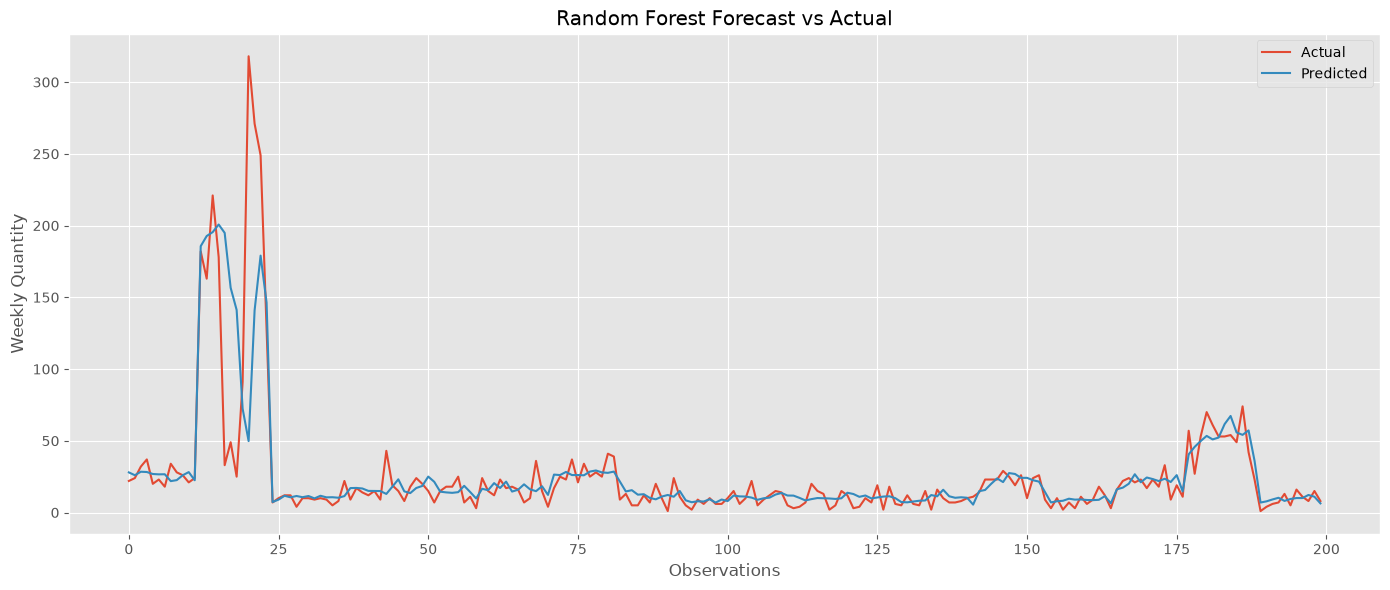

In [86]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    y_pred[:200],
    label="Predicted"
)

plt.title("Random Forest Forecast vs Actual")

plt.xlabel("Observations")

plt.ylabel("Weekly Quantity")

plt.legend()

plt.tight_layout()

plt.show()

### Improved Forecast Model Summary

Additional lag-based and rolling statistical features were introduced to improve forecasting performance. A Random Forest Regressor was retrained using these historical demand features and evaluated using WAPE, MAE, and RMSE. The updated model was compared with the seasonal naive baseline to assess improvements in forecasting accuracy.

## Rolling-Origin Cross-Validation

To evaluate the forecasting model more reliably, Rolling-Origin Cross-Validation is performed. Unlike random cross-validation, this approach preserves the chronological order of the data by repeatedly training on earlier weeks and testing on later weeks. This prevents data leakage and provides a more realistic estimate of forecasting performance.

In [87]:
from sklearn.model_selection import TimeSeriesSplit

In [88]:
tscv = TimeSeriesSplit(n_splits=5)

In [89]:
X = model_data[features]
y = model_data[target]

In [90]:
cv_wape = []

In [91]:
for train_index, test_index in tscv.split(X):

    X_train_cv = X.iloc[train_index]
    X_test_cv = X.iloc[test_index]

    y_train_cv = y.iloc[train_index]
    y_test_cv = y.iloc[test_index]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_cv, y_train_cv)

    pred = model.predict(X_test_cv)

    wape_cv = (
        np.abs(y_test_cv - pred).sum()
        / y_test_cv.sum()
    ) * 100

    cv_wape.append(wape_cv)

In [92]:
for i, score in enumerate(cv_wape, start=1):
    print(f"Fold {i}: {score:.2f}%")

Fold 1: 31.92%
Fold 2: 34.73%
Fold 3: 31.96%
Fold 4: 33.31%
Fold 5: 48.91%


In [93]:
average_wape = np.mean(cv_wape)

print(f"Average CV WAPE: {average_wape:.2f}%")

Average CV WAPE: 36.16%


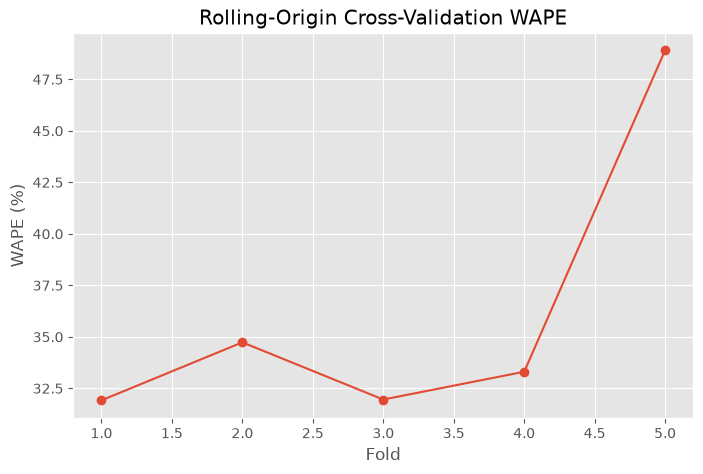

In [94]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cv_wape) + 1),
    cv_wape,
    marker="o"
)

plt.title("Rolling-Origin Cross-Validation WAPE")

plt.xlabel("Fold")

plt.ylabel("WAPE (%)")

plt.grid(True)

plt.show()

### Rolling-Origin Cross-Validation Summary

Rolling-Origin Cross-Validation was performed using five chronological folds. The forecasting model was trained and evaluated across multiple time periods, and WAPE was calculated for each fold. The average WAPE provides a robust estimate of the model's forecasting performance while ensuring that no future information was used during training.